In [15]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp


Una corrección relativista para el problema de dos cuerpos de Kepler, sistema Sol-planeta, puede describirse en coordenadas polares con la ecuación:

$$
\ddot{u}(\theta) + u(\theta) - \frac{1}{\alpha} - \delta u^2(\theta) = 0
$$

Donde $u(\theta) = 1/r(\theta)$, el Sol se encuentra en el origen, $\alpha$ y $\delta$ son constantes. El término con $\delta$ es la corrección relativista.

1. Formular el problema como un sistema de orden uno de la forma $\dot{y} = f(\theta, y)$. Observar que la variable independiente no es el tiempo sino ángulos en polares.

2. Resolver el problema de Kepler $(\delta = 0)$, con condiciones iniciales $r(0) = \alpha/(1+\epsilon)$ y $\dot{r}(0) = 0$. $\epsilon$ es la excentricidad de la órbita: $0 \leq \epsilon < 1$ para órbitas cerradas, $\epsilon \geq 1$ para órbitas abiertas. La condición $\dot{r}(0) = 0$ (velocidad radial cero) significa que medimos los ángulos a partir del perihelio (punto más cercano al Sol).

Graficar soluciones con $\alpha = 1$ para distintos valores de $\epsilon$. Observar qué pasa cuando $\theta > 2\pi$ (3 o 4 vueltas).

In [16]:
def sistema(estado, alpha, delta):
    u, v = estado

    dU_dtheta = v
    dV_dtheta = -u + 1/alpha + delta * u**2

    return np.array([dU_dtheta, dV_dtheta])

In [17]:
def euler(u0, v0, alpha, delta, theta0, thetaf, h):
    num_pasos = int((thetaf - theta0) / h)

    theta = np.linspace(theta0, thetaf, num_pasos + 1)

    U = np.zeros(num_pasos + 1)
    V = np.zeros(num_pasos + 1)

    U[0] = u0
    V[0] = v0

    for i in range(num_pasos):
        estado = np.array([U[i], V[i]])
        pendiente = sistema(estado, alpha, delta)

        U[i+1] = U[i] + h * pendiente[0]
        V[i+1] = V[i] + h * pendiente[1]

    return theta, U, V

3. Resolver el problema relativista para $\delta = 0.05$ en las mismas condiciones iniciales del ítem anterior y comparar.

El efecto se conoce como precesión del perihelio y las mediciones sobre la órbita de Mercurio fueron utilizadas por Albert Einstein como evidencia experimental de la Teoría General de la Relatividad.

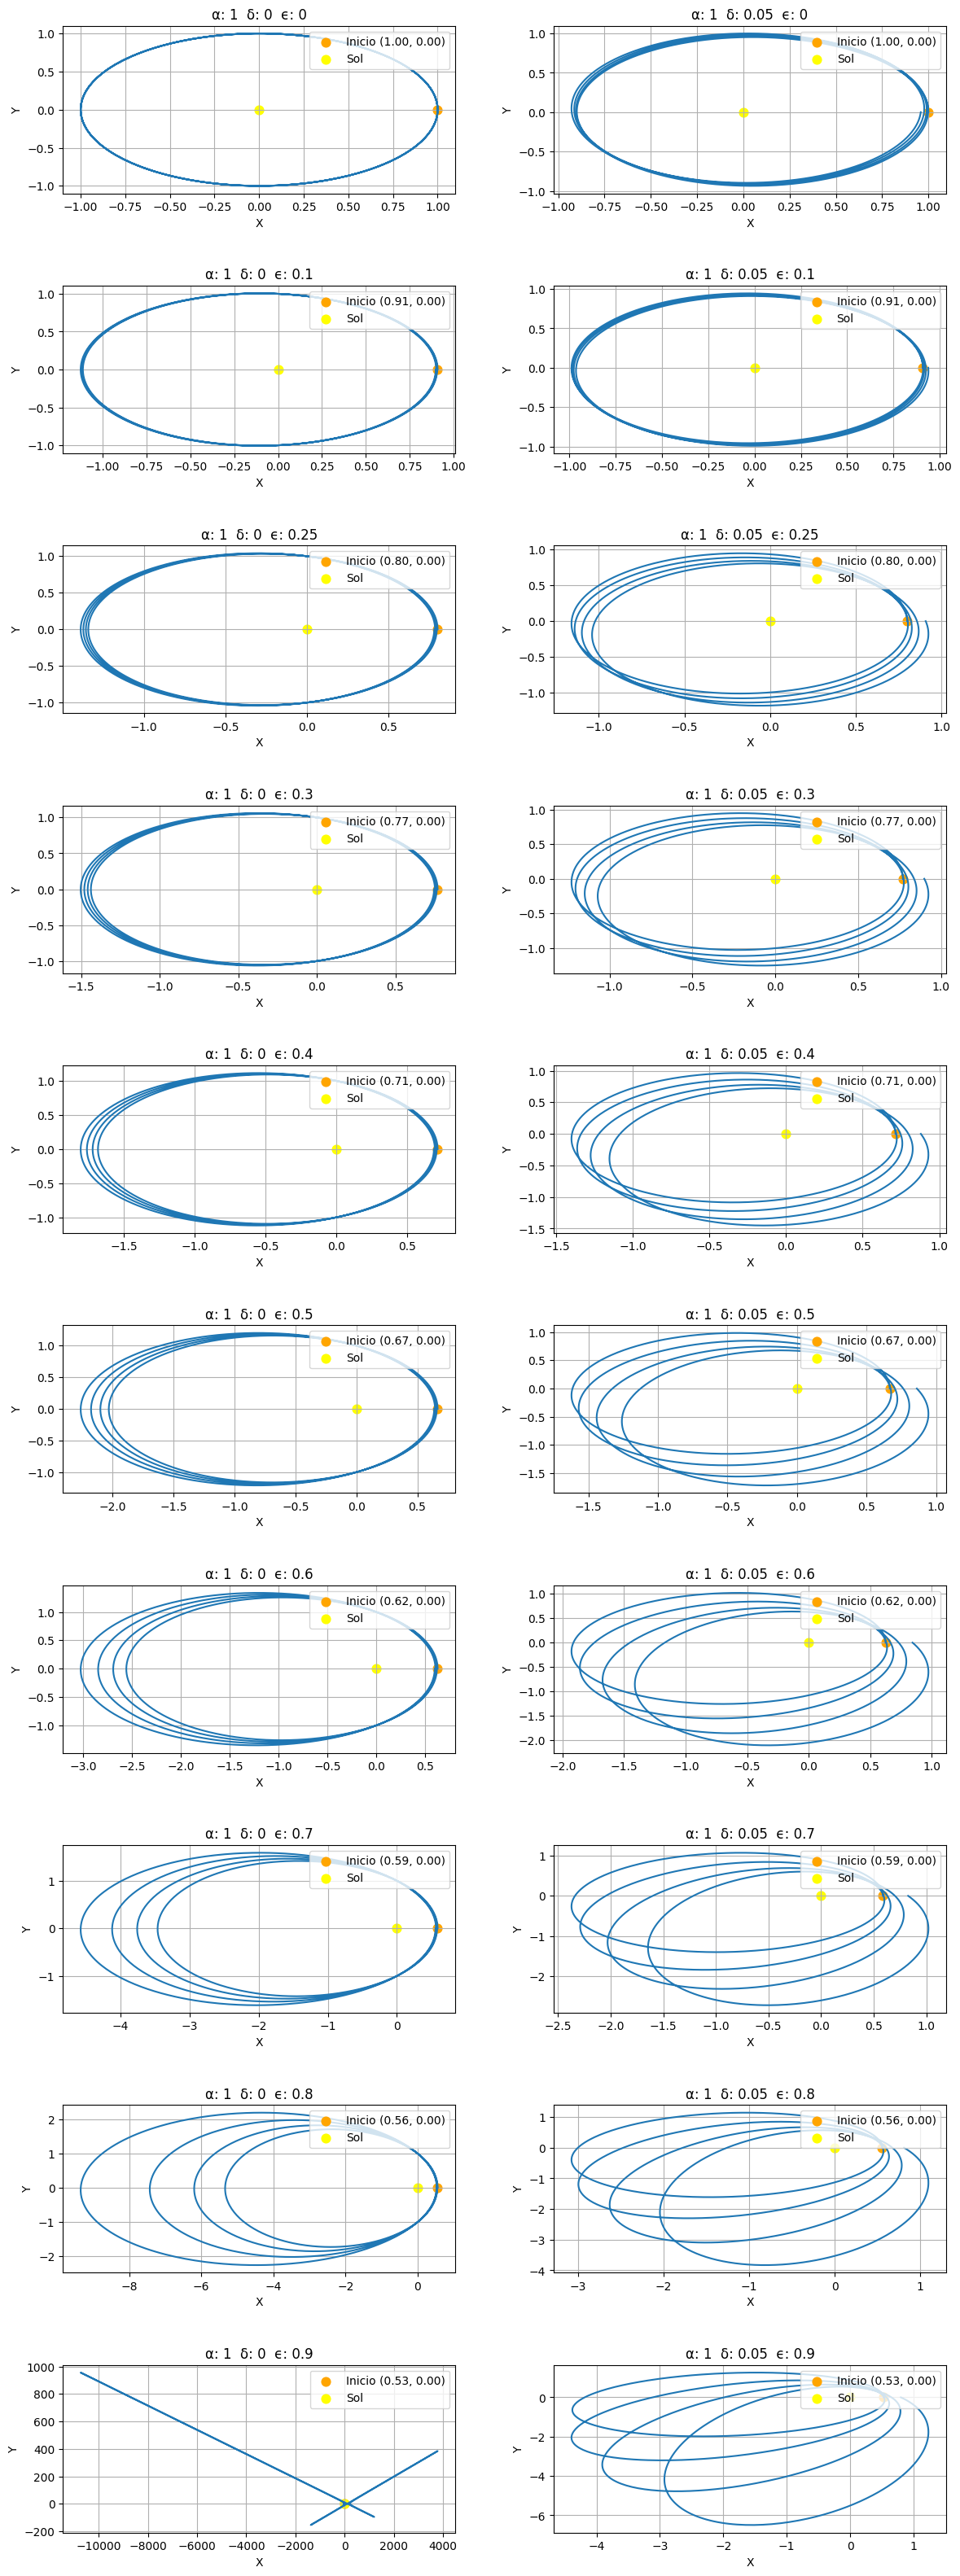

In [48]:
# Parámetros

delta = [0, 0.05]
alpha = 1
epsilon = [0, 0.1, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

theta0 = 0
thetaf = 8 * np.pi
h = 0.01

fig, axes = plt.subplots(len(epsilon), len(delta), figsize=(14, 4*len(epsilon)), gridspec_kw={'hspace': 0.55, 'wspace': 0.25})

for i, ep in enumerate(epsilon):
    for j, d in enumerate(delta):
        
        # r(0) = alpha / (1 + epsilon)
        r0 = alpha / (1 + ep)

        # u = 1/r
        u0 = 1 / r0
        v0 = 0

        theta, U, V = euler(u0, v0, alpha, d, theta0, thetaf, h)

        R = 1 / U

        X = R * np.cos(theta)
        Y = R * np.sin(theta)

        axes[i,j].plot(X, Y)
        axes[i,j].scatter(X[0],Y[0], s=60, color='orange', label=f'Inicio ({X[0]:.2f}, {Y[0]:.2f})')
        axes[i,j].scatter(0,0, s=60, color='yellow', label='Sol')
        axes[i,j].set_xlabel('X')
        axes[i,j].set_ylabel('Y')
        axes[i,j].set_title(f'α: {alpha}  δ: {d}  ϵ: {ep}')
        axes[i,j].grid(True)
        axes[i,j].legend(loc='upper right')
        

    

plt.show()

In [50]:
from scipy.integrate import solve_ivp

def sistema_ivp(theta, y, alpha, delta):
    u, v = y

    dudtheta = v
    dvdtheta = -u + 1/alpha + delta * u**2

    return [dudtheta, dvdtheta]

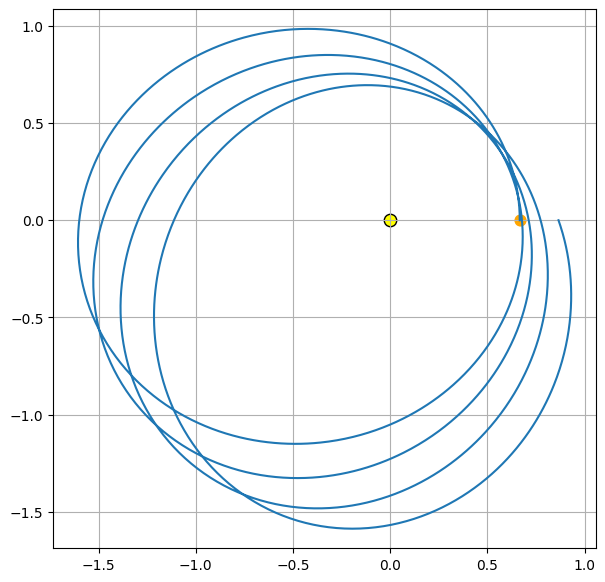

In [51]:
alpha = 1
delta = 0.05
epsilon = 0.5

theta0 = 0
thetaf = 8 * np.pi

r0 = alpha / (1 + epsilon)
u0 = 1 / r0
v0 = 0

y0 = [u0, v0]

theta_eval = np.linspace(theta0, thetaf, 3000)

sol = solve_ivp(
    fun=sistema_ivp,
    t_span=(theta0, thetaf),
    y0=y0,
    t_eval=theta_eval,
    args=(alpha, delta)
)

theta = sol.t
U = sol.y[0]
V = sol.y[1]

R = 1 / U

X = R * np.cos(theta)
Y = R * np.sin(theta)

plt.figure(figsize=(7, 7))
plt.plot(X, Y)
plt.scatter(0, 0, color='yellow', edgecolor='black', s=80)
plt.scatter(X[0], Y[0], color='orange', s=60)
plt.axis('equal')
plt.grid(True)
plt.show()

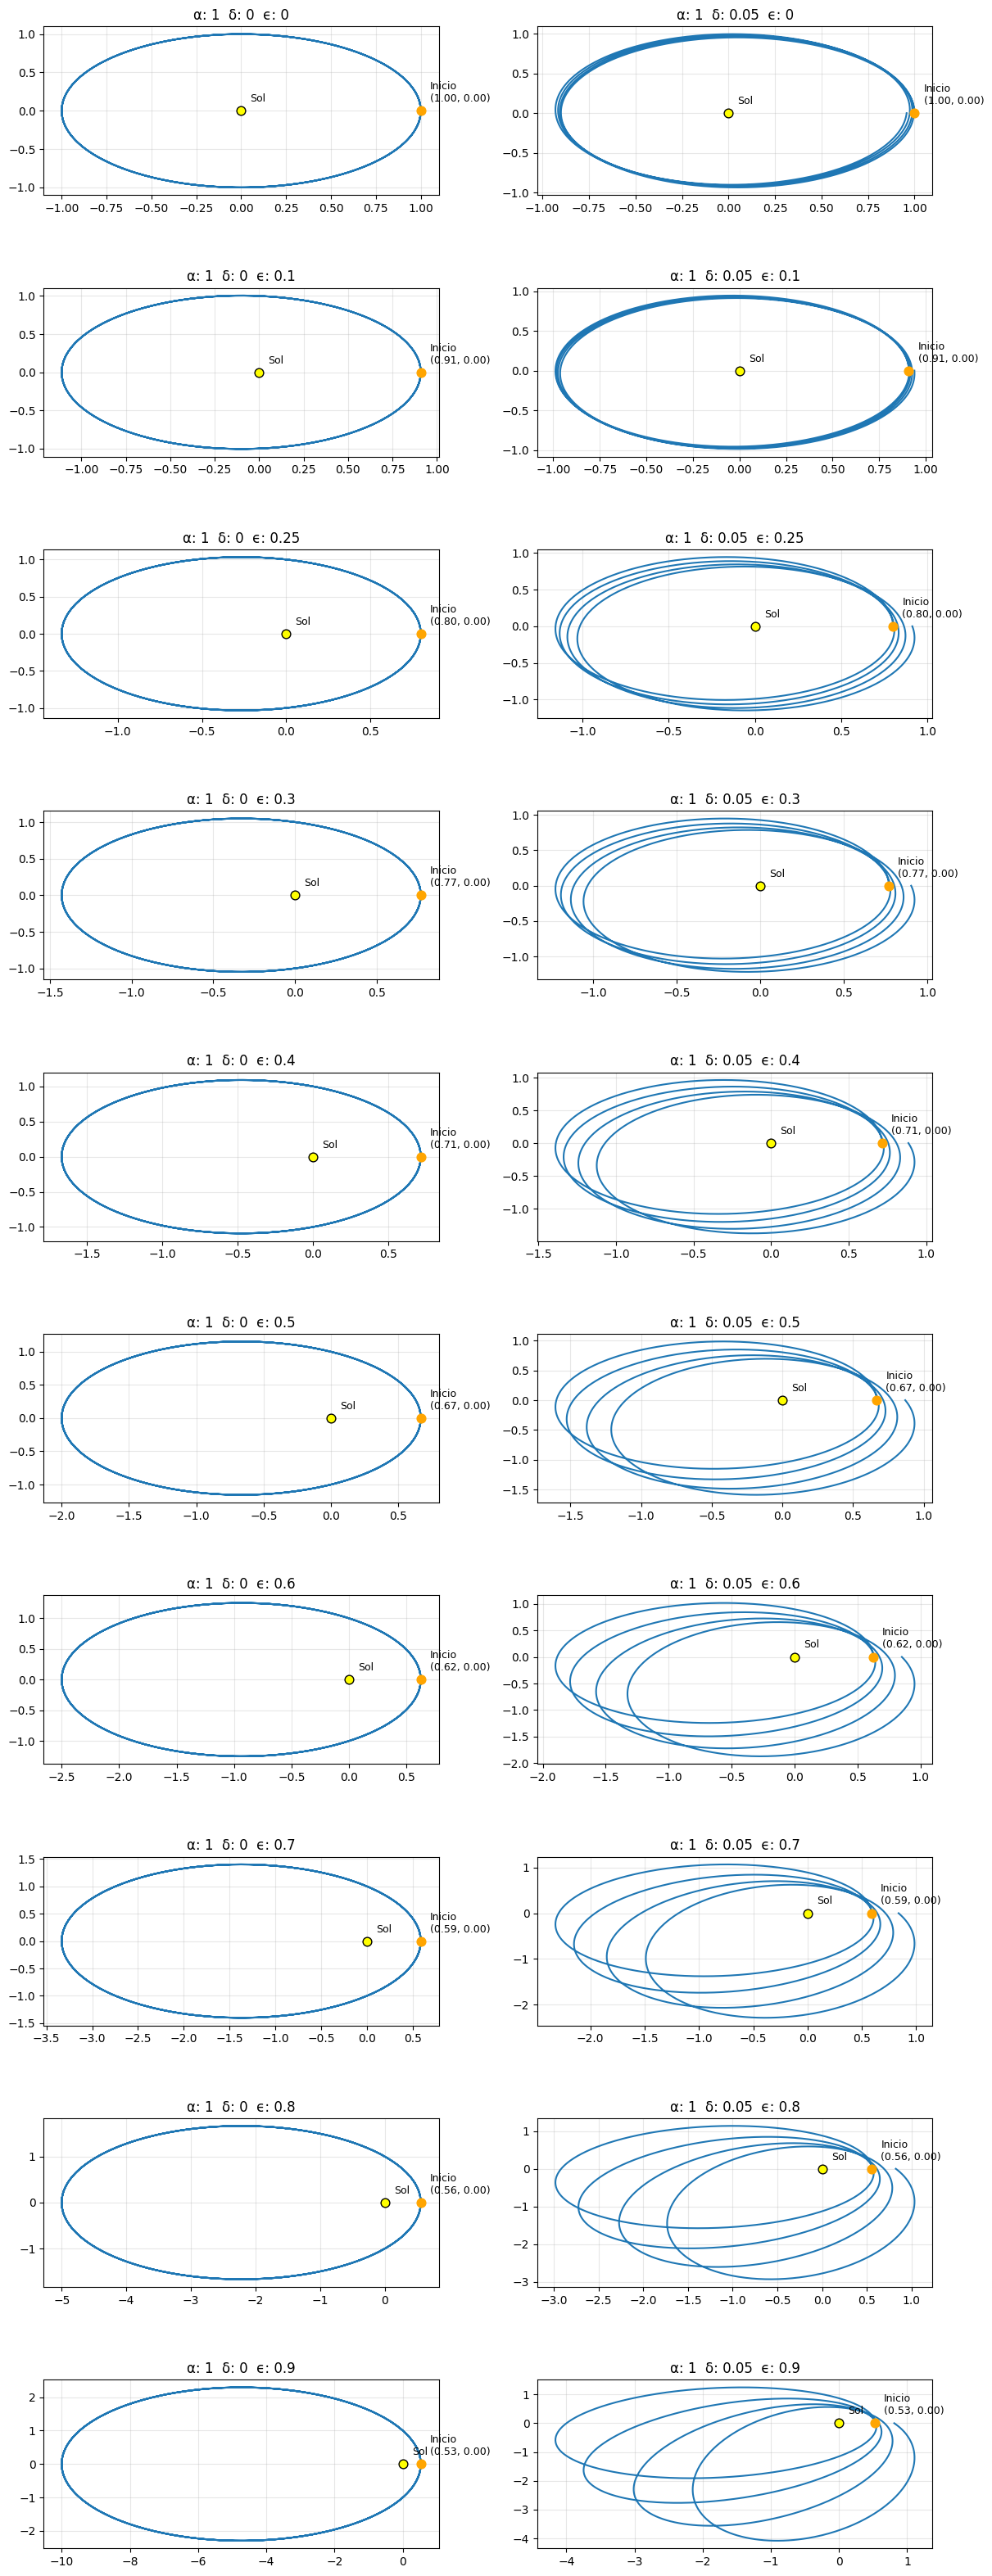

In [53]:
# Parámetros
delta = [0, 0.05]
alpha = 1
epsilon = [0, 0.1, 0.25, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

theta0 = 0
thetaf = 8 * np.pi

# Grilla angular donde queremos evaluar la solución
theta_eval = np.linspace(theta0, thetaf, 3000)

fig, axes = plt.subplots(len(epsilon), len(delta), figsize=(14, 4*len(epsilon)), gridspec_kw={'hspace': 0.55, 'wspace': 0.25})

for i, ep in enumerate(epsilon):
    for j, d in enumerate(delta):

        r0 = alpha / (1 + ep)
        u0 = 1 / r0
        v0 = 0

        y0 = [u0, v0]

        sol = solve_ivp(
            fun=sistema_ivp,
            t_span=(theta0, thetaf),
            y0=y0,
            t_eval=theta_eval,
            args=(alpha, d),
            rtol=1e-9,
            atol=1e-11
        )

        theta = sol.t
        U = sol.y[0]
        V = sol.y[1]

        R = 1 / U

        X = R * np.cos(theta)
        Y = R * np.sin(theta)

        ax = axes[i, j]

        ax.plot(X, Y, linewidth=1.5)

        # Punto inicial
        ax.scatter(X[0], Y[0], s=60, color='orange', zorder=3)
        ax.annotate(
            f'Inicio\n({X[0]:.2f}, {Y[0]:.2f})',
            xy=(X[0], Y[0]),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=9
        )

        # Sol
        ax.scatter(0, 0, s=60, color='yellow', edgecolor='black', zorder=3)
        ax.annotate(
            'Sol',
            xy=(0, 0),
            xytext=(8, 8),
            textcoords='offset points',
            fontsize=9
        )
        ax.set_title(f'α: {alpha}  δ: {d}  ϵ: {ep}')
        ax.grid(True, alpha=0.3)
        

plt.show()